# CO<sub>2</sub> Emissions Regression — Portfolio Project

**Author:** Tim  
**Dataset:** Our World in Data – CO<sub>2</sub> and Greenhouse Gas Emissions  
**Objective:** Predict temperature change from energy, economic, and demographic features using multiple regression models.

*Data source: [Our World in Data – CO₂ and Greenhouse Gas Emissions](https://github.com/owid/co2-data)*

---

## 1. Introduction

### Problem Statement
CO<sub>2</sub> emissions are the primary driver of anthropogenic climate change. Accurately predicting a country's annual emissions from economic and energy indicators helps policymakers design evidence-based climate targets.

### Goal
Build and compare five regression models to predict a country's Country's share of global temp change.

**Features used:**
- **Energy:** primary energy consumption, coal, oil, gas, cement, flaring emissions
- **Economic:** GDP
- **Demographic:** population
- **Temporal:** year

**Modeling approach:**
1. Linear Regression (baseline)
2. Ridge Regression (L2 regularization)
3. Lasso Regression (L1 — implicit feature selection)
4. Random Forest (bagging ensemble)
5. Gradient Boosting (boosting ensemble)

> **Target variable:** `share_of_temperature_change_from_ghg` — the heavily right-skewed target is log-transformed to stabilise variance and improve linear model performance.

## Step 1: Setup & Imports
**Concept**: Before any data science work begins, you load all the tools (libraries) your project will need. Think of it like gathering all your equipment before starting an experiment.

**Why necessary**:
Libraries help in manipulating the dataset, visualizing data, processing, training, evaluating and saving models.

**What I've learnt**:
Every data science project starts with imports — it's standard practice
Libraries are grouped by purpose (data, visualization, ML) for readability
pd.set_option('display.max_columns', None) ensures you see all columns when previewing the dataframe, not a truncated view

In [65]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV


# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Persistence
import joblib

# Os
import os

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2: Load & Explore the Data (EDA)
**Concept**: EDA (Exploratory Data Analysis) is the process of understanding your dataset before touching it. You look at its shape, data types, missing values, and how the target variable is distributed. It's the most important step in any ML project.

**Why necessary:**
You can't make good modeling decisions without first understanding your data
Reveals missing values early so you plan how to handle them
Helps you spot outliers that could skew your model

**Key observations from this dataset**:

some columns can't fit directly into the model
some columns have largely missing values and are likely to be dropped.

What I've learnt:

EDA is not optional — it directly informs every decision you make in later steps
Missing % matters more than missing count — a column missing 80% of its data is usually not worth keeping
Always visualize your target variable first — a heavily skewed target may need log transformation before modeling
df.info() and df.describe() together give you a complete picture of your data's health

In [2]:
URL = 'https://raw.githubusercontent.com/owid/co2-data/refs/heads/master/owid-co2-data.csv'
data = pd.read_csv(URL)
print(f"Shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
data.head()

Shape: 50,411 rows x 79 columns


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,50411.0,1.920349e+03,6.585912e+01,1.750000e+03,1.875000e+03,1.925000e+03,1.975000e+03,2.024000e+03
population,41167.0,6.017453e+07,3.308433e+08,2.150000e+02,3.272140e+05,2.291594e+06,9.986553e+06,8.161973e+09
gdp,15251.0,3.300495e+11,3.086383e+12,4.998000e+07,7.874038e+09,2.743861e+10,1.212627e+11,1.301126e+14
cement_co2,29173.0,7.890109e+00,6.298817e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.240000e-01,1.666885e+03
cement_co2_per_capita,25648.0,6.001252e-02,1.235623e-01,0.000000e+00,0.000000e+00,1.000000e-03,7.625000e-02,2.484000e+00
...,...,...,...,...,...,...,...,...
temperature_change_from_n2o,38280.0,5.090648e-04,3.047886e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.500000e-02
total_ghg,38150.0,4.907996e+02,2.414077e+03,-1.972500e+01,1.502000e+00,1.460550e+01,7.650850e+01,5.443340e+04
total_ghg_excluding_lucf,37813.0,3.105215e+02,1.812364e+03,0.000000e+00,2.210000e-01,2.222000e+00,2.786300e+01,4.371478e+04
trade_co2,4712.0,-6.986781e+00,2.590182e+02,-2.177807e+03,-2.262250e+00,1.641000e+00,1.142550e+01,1.768846e+03


In [4]:
# Check for missing values and their percentages
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                                      Missing Count  Missing %
share_global_cumulative_other_co2             48241      95.70
share_global_other_co2                        48241      95.70
other_co2_per_capita                          47752      94.73
other_industry_co2                            47157      93.55
cumulative_other_co2                          47157      93.55
...                                             ...        ...
population                                     9244      18.34
share_of_temperature_change_from_ghg           9173      18.20
temperature_change_from_co2                    9173      18.20
temperature_change_from_ghg                    9173      18.20
iso_code                                       7931      15.73

[77 rows x 2 columns]


### Step 3: Handling Missing Values
**Concept**: Missing data is when cells in your dataset have no value (NaN).  This dataset contains large missing values and therefore requires efficient strategies to deal with it.

**Why necessary**:
- Most algorithms may not handle missing data well
- Dropping too many columns loses valuable information
- Wrong imputation strategy can bias the model's predictions

**Strategies for this dataset**:
- Drop columns with more than 50% missing data
- Drop target rows with missing values
- Median imputation for remaining numeric columns - median is robust to outliers unlike mean. 
- Drop non-numeric columns (country, iso_code) - handled later in feature engineering

In [5]:
# Always make a copy of the original DataFrame before making any modifications
df_clean = data.copy()

print("Original shape:", data.shape)
print("Working copy shape:", df_clean.shape)

Original shape: (50411, 79)
Working copy shape: (50411, 79)


In [6]:
# Drop rows without a target value
df_clean = df_clean.dropna(subset=['temperature_change_from_ghg'])

print("Shape after dropping missing target rows:", df_clean.shape)


Shape after dropping missing target rows: (41238, 79)


In [7]:
# Calculate missing percentage per column
missing_pct = df_clean.isnull().sum() / len(df_clean) * 100

# Identify columns to drop
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()

print(f"Columns to drop ({len(cols_to_drop)}):\n", cols_to_drop)

# Drop them
df_clean = df_clean.drop(columns=cols_to_drop)

print("\nShape after dropping high-missing columns:", df_clean.shape)

Columns to drop (33):
 ['gdp', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'other_co2_per_capita', 'other_industry_co2', 'primary_energy_consumption', 'share_global_coal_co2', 'share_global_cumulative_coal_co2', 'share_global_cumulative_flaring_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_other_co2', 'share_global_flaring_co2', 'share_global_gas_co2', 'share_global_other_co2', 'trade_co2', 'trade_co2_share']

Shape after dropping high-missing columns: (41238, 46)


In [8]:
# Drop text columns - can't impute or use directly in regression
df_clean = df_clean.drop(columns=['country', 'iso_code'], errors='ignore')

print("Shape after dropping text columns:", df_clean.shape)
print("\nRemaining dtypes:\n", df_clean.dtypes.value_counts())

Shape after dropping text columns: (41238, 44)

Remaining dtypes:
 float64    43
int64       1
Name: count, dtype: int64


In [9]:
# Fill remaining NaN values with each column's median
imputer = SimpleImputer(strategy='median')

df_clean = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

# Confirm no missing values remain
print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)

Missing values remaining: 0
Final shape: (41238, 44)


In [10]:
# Summary statistics of the cleaned DataFrame
df_clean.describe()


,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_luc_co2,cumulative_oil_co2,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
count,41238.000000,4.123800e+04,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,4.123800e+04,4.123800e+04,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000,41238.000000
mean,1937.500000,5.538298e+07,5.601468,0.040428,212.193189,4.105575,28.172190,325.651621,4.312141,2.863435,6.016152,2.910192,139.126946,8.336843e+03,1.654409e+04,9112.893026,2315.805353,2.764684,7.279012,113.306842,3.588686,88.265711,1.649548,23.769551,0.418372,70.814928,1.515136,1.635170,2.142370,2.060048,1.628503,2.218635,1.968256,2.322253,1.951485,2.210034,1.940886,2.272236,0.002665,0.008014,0.011224,0.000473,454.674792,284.835475
std,50.229253,3.267138e+08,53.097762,0.100612,1425.119011,50.568791,1373.195747,1745.490756,75.202799,126.036727,6.857228,11.538512,1260.869647,6.006621e+04,9.734747e+04,43965.688950,19629.784916,7.303361,10.523692,496.259379,8.548470,418.750513,3.592746,125.659794,0.745073,510.682379,10.831519,9.950763,10.592387,9.018151,10.001099,11.281208,8.983101,9.313381,10.211423,9.337716,10.036540,9.282343,0.014820,0.045687,0.062888,0.002939,2325.209329,1737.556681
min,1851.000000,2.220000e+02,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,-11927.241000,-12.455000,0.000000,0.000000,0.000000e+00,-1.203450e+02,-3918.006000,0.000000,0.022000,-28.852000,-319.418000,-45.317000,0.000000,0.032000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.375000,0.000000,0.000000,-0.101000,-0.518000,0.000000,-6.966000,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000
25%,1894.000000,4.882140e+05,0.002000,0.002000,2.077250,0.011000,2.113250,20.221250,0.015000,0.390250,3.762250,0.691000,0.058000,3.593800e+01,6.834832e+02,30.099500,16.456000,0.309000,2.203000,0.133000,0.234000,0.532000,0.681000,0.091000,0.125000,0.974250,0.305000,0.019000,0.022000,0.125000,0.014000,0.012000,0.096000,0.016000,0.031000,0.003000,0.038000,0.003000,0.000000,0.000000,0.000000,0.000000,2.101250,0.287250
50%,1937.500000,2.536365e+06,0.046000,0.007000,4.644000,0.051000,3.897000,28.127000,0.112000,1.183000,4.536000,1.181000,0.538000,9.189800e+01,1.045753e+03,303.724000,31.563000,0.665000,4.291000,3.578000,1.301000,3.492000,1.007000,0.715000,0.225000,1.764000,0.469500,0.029000,0.051000,0.175000,0.023000,0.029000,0.143000,0.109000,0.056000,0.076500,0.065000,0.081000,0.000000,0.000000,0.000000,0.000000,14.727500,2.265000
75%,1981.000000,8.537978e+06,0.127000,0.016000,10.058500,0.179000,5.562000,39.694750,0.326750,2.021000,5.430750,2.006000,1.716750,2.276095e+02,1.574702e+03,1436.564250,58.532000,2.212750,8.224250,19.111000,3.568000,15.694000,1.561000,4.501750,0.414000,2.924000,0.7

#### What I've learnt:

- Always make a copy of the original dataframe before any manipulation — df.copy() not df_clean = df(that just creates a reference, not a true copy)
- Drop target-missing rows before anything else — no point cleaning what you can't use
- The 50% threshold for dropping columns is a common industry rule of thumb, not a fixed law — context matters
- SimpleImputer from sklearn is cleaner than data.fillna() because it integrates directly into sklearn pipelines later
errors='ignore' in drop() prevents crashes if a column name doesn't exist

## Step 4: Feature Selection
**Concept**: Feature selection is the process of choosing only the most relevant columns (features) to feed into your model. Not every column in the dataset helps the model learn — some are redundant, some are too similar to the target, and some just add noise.

**Why necessary**:
- Too many features slow down training and can confuse the model
- Highly correlated features (multicollinearity) can destabilize regression models
- Some features are just transformed versions of the target — using them would be data leakage (model cheats by seeing the answer)
- Better features = better model performance and interpretability

**Strategies for this dataset**:

- Remove leakage columns — columns that are direct derivatives of temperature_change_from_ghg (e.g. temperature_change_from_co2, temperature_change_from_ch4)
- Remove highly correlated features — if two features are 95%+ correlated, one is redundant
Use correlation with target — keep features that have meaningful relationship with temperature_change_from_ghg

### Seperate features and target variables before dropping columns

In [12]:
# Separate target immediately after cleaning — before any feature selection
y = df_clean['temperature_change_from_ghg'].copy()
X = df_clean.drop(columns=['temperature_change_from_ghg'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41238, 43)
y shape: (41238,)


In [13]:
leakage_cols = [
    'temperature_change_from_co2',
    'temperature_change_from_ch4',
    'temperature_change_from_n2o',
    'share_of_temperature_change_from_ghg'
]

X = X.drop(columns=leakage_cols, errors='ignore')
print("Shape after removing leakage columns:", X.shape)

Shape after removing leakage columns: (41238, 39)


In [14]:
# Use corrwith() — correlates X columns against y directly
target_corr = X.corrwith(y).abs().sort_values(ascending=False)
print(target_corr)

total_ghg_excluding_lucf                     0.975390
total_ghg                                    0.973503
nitrous_oxide                                0.961656
cumulative_co2_including_luc                 0.940507
methane                                      0.936562
co2_including_luc                            0.920957
co2                                          0.917567
oil_co2                                      0.907004
cumulative_co2                               0.904458
cumulative_luc_co2                           0.889341
cumulative_oil_co2                           0.877736
cumulative_cement_co2                        0.826257
population                                   0.806450
cement_co2                                   0.764697
share_global_cumulative_co2_including_luc    0.671037
share_global_co2_including_luc               0.647477
share_global_cumulative_luc_co2              0.635056
share_global_cumulative_cement_co2           0.626129
land_use_change_co2         

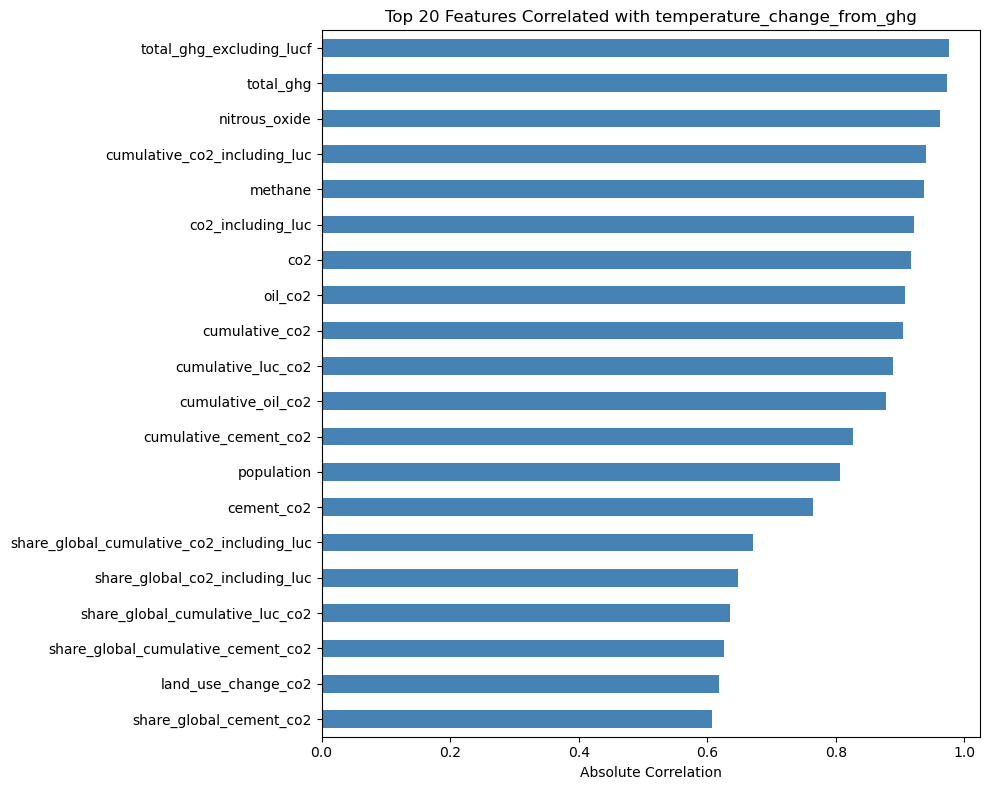

In [15]:
# Visualize top 20
plt.figure(figsize=(10, 8))
target_corr[:20].plot(kind='barh', color='steelblue')
plt.title("Top 20 Features Correlated with temperature_change_from_ghg")
plt.xlabel("Absolute Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
low_corr_cols = target_corr[target_corr < 0.01].index.tolist()
print(f"Low correlation columns to drop ({len(low_corr_cols)}):\n", low_corr_cols)

X = X.drop(columns=low_corr_cols, errors='ignore')
print("\nX shape after dropping low correlation features:", X.shape)

Low correlation columns to drop (4):
 ['oil_co2_per_capita', 'co2_growth_prct', 'co2_including_luc_growth_prct', 'methane_per_capita']

X shape after dropping low correlation features: (41238, 35)


In [17]:
corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

highly_correlated = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.95)
]

print(f"Highly correlated columns to drop ({len(highly_correlated)}):\n", highly_correlated)

X = X.drop(columns=highly_correlated, errors='ignore')
print("\nFinal X shape after feature selection:", X.shape)

Highly correlated columns to drop (14):
 ['co2_including_luc', 'cumulative_co2_including_luc', 'cumulative_luc_co2', 'cumulative_oil_co2', 'nitrous_oxide', 'oil_co2', 'share_global_cumulative_cement_co2', 'share_global_cumulative_co2', 'share_global_cumulative_co2_including_luc', 'share_global_cumulative_luc_co2', 'share_global_luc_co2', 'share_global_oil_co2', 'total_ghg', 'total_ghg_excluding_lucf']

Final X shape after feature selection: (41238, 21)


In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFinal features:\n", X.columns.tolist())

# Confirm target is safe
print("\nTarget sample:")
print(y.head())

X shape: (41238, 21)
y shape: (41238,)

Final features:
 ['year', 'population', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_including_luc_growth_abs', 'co2_including_luc_per_capita', 'co2_per_capita', 'cumulative_cement_co2', 'cumulative_co2', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'nitrous_oxide_per_capita', 'share_global_cement_co2', 'share_global_co2', 'share_global_co2_including_luc', 'share_global_cumulative_oil_co2']

Target sample:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: temperature_change_from_ghg, dtype: float64


#### What I've learnt:
- Data leakage is one of the most dangerous mistakes in ML — always ask "would I have this column at prediction time in the real world?" If no, drop it
- Separate X and y as early as possible — it prevents the target from ever being accidentally dropped, filtered, or transformed during feature selection
- `corrwith()` is safer than `.corr()` for feature-target correlation because it operates on X and y independently — the target can never accidentally end up in low_corr_cols

## Step 5: Feature Engineering
**Concept**: Feature engineering is the process of creating new meaningful features from existing ones, or transforming existing features to make them more useful for the model. It's where domain knowledge meets data science.
**Why necessary**:

- Raw features don't always capture the full story in the data
- Models learn better from well-constructed features than raw numbers
- Can significantly boost model performance without adding more data
- Demonstrates deeper understanding of the dataset

**Strategies for this dataset**:

- Decade feature — group years into decades to capture emission trends over time
- CO2 per energy unit — already exists but we'll verify it's in our feature set
- Emission intensity ratio — how much GHG relative to total CO2
- Log transformation — some emission columns are heavily skewed, log smooths them out

In [19]:
# Group years into decades — captures era-level emission trends
X['decade'] = (X['year'] // 10) * 10

print("Decades in dataset:", sorted(X['decade'].unique()))

Decades in dataset: [np.float64(1850.0), np.float64(1860.0), np.float64(1870.0), np.float64(1880.0), np.float64(1890.0), np.float64(1900.0), np.float64(1910.0), np.float64(1920.0), np.float64(1930.0), np.float64(1940.0), np.float64(1950.0), np.float64(1960.0), np.float64(1970.0), np.float64(1980.0), np.float64(1990.0), np.float64(2000.0), np.float64(2010.0), np.float64(2020.0)]


In [20]:
# Check if 'total_ghg' is still present after all the drops
print('total_ghg' in X.columns)

False


In [21]:
# GHG to CO2 ratio — only create if both columns exist
if 'total_ghg' in X.columns and 'co2' in X.columns:
    X['ghg_to_co2_ratio'] = np.where(
        X['co2'] > 0,
        X['total_ghg'] / X['co2'],
        0
    )
    print("ghg_to_co2_ratio created using total columns")
else:
    # Use available GHG per capita columns instead
    if 'ghg_per_capita' in X.columns and 'co2_per_capita' in X.columns:
        X['ghg_to_co2_ratio'] = np.where(
            X['co2_per_capita'] > 0,
            X['ghg_per_capita'] / X['co2_per_capita'],
            0
        )
        print("ghg_to_co2_ratio created using per_capita columns")
    else:
        print("Skipping ghg_to_co2_ratio — required columns not available")

ghg_to_co2_ratio created using per_capita columns


In [22]:
# Identify highly skewed numeric columns
skewness = X.skew().sort_values(ascending=False)
highly_skewed = skewness[skewness.abs() > 1].index.tolist()

print(f"Highly skewed columns ({len(highly_skewed)}):\n", highly_skewed)

Highly skewed columns (21):
 ['co2_per_capita', 'ghg_to_co2_ratio', 'cumulative_cement_co2', 'cement_co2', 'cumulative_co2', 'co2', 'population', 'ghg_excluding_lucf_per_capita', 'land_use_change_co2_per_capita', 'methane', 'co2_including_luc_per_capita', 'share_global_cement_co2', 'nitrous_oxide_per_capita', 'land_use_change_co2', 'share_global_co2_including_luc', 'share_global_cumulative_oil_co2', 'co2_growth_abs', 'share_global_co2', 'ghg_per_capita', 'cement_co2_per_capita', 'co2_including_luc_growth_abs']


In [23]:
# Apply log1p transformation to handle skewness, adding 1 to avoid log(0) issues
for col in highly_skewed:
    X[col] = np.log1p(X[col].clip(lower=0))  # clip negatives to 0 first

print("Log transformation applied to skewed columns.")

Log transformation applied to skewed columns.


In [24]:
print("New features added:")
print([col for col in X.columns if col in ['decade', 'ghg_to_co2_ratio']])

print("\nUpdated X shape:", X.shape)
print("\nSample of engineered features:")
X[['year', 'decade', 'ghg_to_co2_ratio']].head(10)

New features added:
['decade', 'ghg_to_co2_ratio']

Updated X shape: (41238, 23)

Sample of engineered features:


,year,decade,ghg_to_co2_ratio
0,1851.0,1850.0,0.996789
1,1852.0,1850.0,0.999286
2,1853.0,1850.0,1.001155
3,1854.0,1850.0,1.003020
4,1855.0,1850.0,1.004881
5,1856.0,1850.0,1.006430
6,1857.0,1850.0,1.007976
7,1858.0,1850.0,1.009212
8,1859.0,1850.0,1.010446
9,1860.0,1860.0,1.012909


In [25]:
# Confirm no NaN or infinite values crept in
print("NaN values in X:", X.isnull().sum().sum())
print("Infinite values in X:", np.isinf(X).sum().sum())

# Replace any infinite values that log transform may have missed
X = X.replace([np.inf, -np.inf], 0)

print("\nAfter cleanup:")
print("NaN values in X:", X.isnull().sum().sum())
print("Infinite values in X:", np.isinf(X).sum().sum())
print("Final X shape:", X.shape)

NaN values in X: 0
Infinite values in X: 0

After cleanup:
NaN values in X: 0
Infinite values in X: 0
Final X shape: (41238, 23)


What I've learnt:

Feature engineering is where creativity meets data science — there's no single right answer, you experiment and validate
log1p is the safe standard for transforming right-skewed emission data
Always check for NaN and inf after any transformation — they can appear silently
Creating a decade feature is a simple but powerful way to help a model understand time-based trends without treating every year as completely unique
np.where(condition, value_if_true, value_if_false) is the vectorized way to do conditional column creation — much faster than loops

## Step 6: Train/Test Split
**Concept**: Splitting your data into a training set and a test set simulates how your model will perform on data it has never seen before. You train on one portion and evaluate on the other.
**Why necessary**:

- If you train and test on the same data, your model scores perfectly but fails in the real world — this is called overfitting
- The test set acts as a "final exam" — the model never sees it during training
- Gives you an honest estimate of real-world model performance
- Standard industry practice — no ML project skips this step

**Strategies for this dataset**:

80/20 split — 80% training, 20% testing. With 40,000+ rows we have enough data for this to be reliable
random_state=42 — fixes the random seed so your split is reproducible every time you run the notebook
shuffle=True — ensures data is randomly mixed before splitting since our data is ordered by country and year


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducibility
    shuffle=True         # mix before splitting
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32990, 23)
X_test shape: (8248, 23)
y_train shape: (32990,)
y_test shape: (8248,)


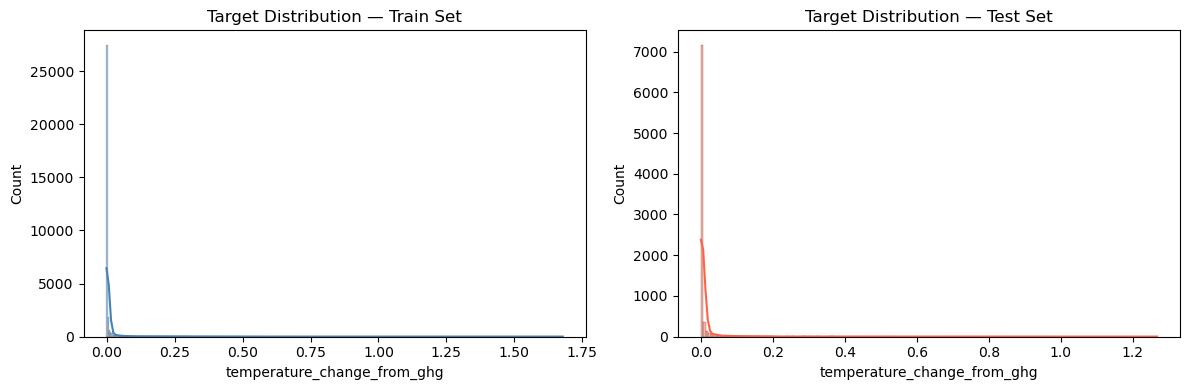

Train target mean: 0.0116
Test target mean: 0.0097


In [27]:
# Check that target distribution is similar in train and test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True, color='steelblue')
plt.title("Target Distribution — Train Set")

plt.subplot(1, 2, 2)
sns.histplot(y_test, kde=True, color='tomato')
plt.title("Target Distribution — Test Set")

plt.tight_layout()
plt.show()

print("Train target mean:", y_train.mean().round(4))
print("Test target mean:", y_test.mean().round(4))

In [28]:
# Confirm train and test indices don't overlap
train_idx = set(X_train.index)
test_idx = set(X_test.index)

overlap = train_idx.intersection(test_idx)
print("Index overlap between train and test:", len(overlap))
# Should print 0 — any overlap means leakage

Index overlap between train and test: 0


What I've learnt:

The train/test split is your model's integrity check — without it you have no way of knowing if your model actually learned anything
random_state=42 is a convention in the data science community — it makes your results reproducible so others can verify your work
shuffle=True is critical for this dataset because the data is sorted by country and year — without shuffling, your test set would only contain recent years which biases evaluation
The four variables X_train, X_test, y_train, y_test are universal naming conventions in ML — any data scientist will immediately understand what they represent
Always verify that train and test target distributions match — a mismatch is a sign something went wrong in your split

## Step 7: Feature Scaling
**Concept**: Feature scaling transforms all numeric features to the same scale. Without it, a column with values in the millions (like co2) dominates a column with values between 0 and 1 (like share_global_co2), causing the model to unfairly weight larger numbers.
**Why necessary**:

Regression models are sensitive to the magnitude of feature values
Features on different scales cause the model to assign wrong importance to features
Scaling speeds up model training significantly
Required for distance-based and gradient-based algorithms to work correctly
Makes model coefficients comparable across features

**Strategies for this dataset**:

StandardScaler — transforms each feature to have mean=0 and std=1. Best choice for regression with normally distributed features
Fit on training data only — then transform both train and test. Fitting on test data would be leakage
Never fit the scaler on the full dataset before splitting — that leaks test set statistics into training

In [29]:
# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data — never on full dataset or test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, no fit

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (32990, 23)
X_test_scaled shape: (8248, 23)


In [30]:
# Convert back to dataframe for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("Mean of each feature (should be ~0):")
print(X_train_scaled_df.mean().round(3).head(10))

print("\nStd of each feature (should be ~1):")
print(X_train_scaled_df.std().round(3).head(10))

Mean of each feature (should be ~0):
year                            0.0
population                      0.0
cement_co2                      0.0
cement_co2_per_capita           0.0
co2                             0.0
co2_growth_abs                  0.0
co2_including_luc_growth_abs   -0.0
co2_including_luc_per_capita   -0.0
co2_per_capita                  0.0
cumulative_cement_co2          -0.0
dtype: float64

Std of each feature (should be ~1):
year                            1.0
population                      1.0
cement_co2                      1.0
cement_co2_per_capita           1.0
co2                             1.0
co2_growth_abs                  1.0
co2_including_luc_growth_abs    1.0
co2_including_luc_per_capita    1.0
co2_per_capita                  1.0
cumulative_cement_co2           1.0
dtype: float64


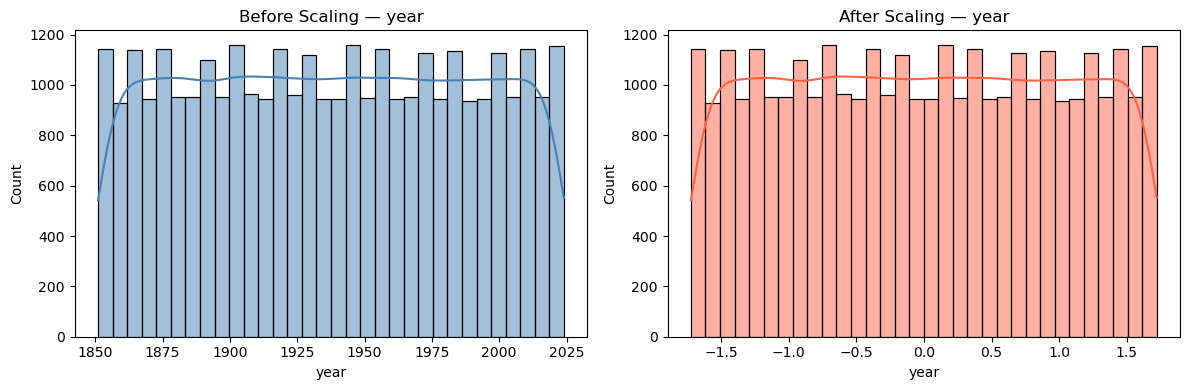

In [31]:
# Visualize distribution of a few features before and after scaling
# Pick one feature to visualize the effect of scaling
sample_col = X_train.columns[0]
sample_idx = X_train.columns.tolist().index(sample_col)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(X_train[sample_col], kde=True, color='steelblue')
plt.title(f"Before Scaling — {sample_col}")

plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled_df[sample_col], kde=True, color='tomato')
plt.title(f"After Scaling — {sample_col}")

plt.tight_layout()
plt.show()

What I've learnt:

Always fit the scaler on training data only - fitting on test or full data is one of the most common and subtle forms of data leakage
fit_transform() does two things at once - learns the statistics (fit) and applies the transformation (transform). On test data you only call transform() because the statistics are already learned
StandardScaler doesn't change the shape of your distribution — it just shifts and rescales it. A skewed feature stays skewed, it's just on a new scale
Not all models need scaling - tree-based models like Random Forest and Gradient Boosting are scale-invariant. But still works with scaled data

## Step 8: Training Models
**Concept**: This is where you actually build your ML models. You'll train multiple models on the same data and compare them — a standard industry practice called model comparison. No single algorithm is always best, so you let the data decide.
**Why necessary**:

Different algorithms learn patterns differently — one may suit your data better than others
Training multiple models gives you a benchmark to compare against
Helps you understand the tradeoff between model simplicity and performance
A portfolio project with multiple models shows hiring managers you understand the ML landscape

**Models we'll train**:
| Model                     | Type               | Why include it                                                    |
| ------------------------- | ------------------ | ----------------------------------------------------------------- |
| LinearRegression          | Simple baseline    | Every project needs a baseline to beat                            |
| Ridge                     | Regularized linear | Handles multicollinearity better than plain linear regression     |
| DecisionTreeRegressor     | Tree-based         | Captures nonlinear patterns and is easy to interpret              |
| RandomForestRegressor     | Ensemble           | Usually a top performer and robust to overfitting                 |
| GradientBoostingRegressor | Ensemble           | Often achieves the best accuracy by learning from previous errors |


In [32]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("Models defined")
print("Total models to train:", len(models))

Models defined
Total models to train: 5


In [33]:

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }
    
    print(f" {name} — R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

print("\nAll models trained")

Training Linear Regression...
 Linear Regression — R2: 0.5295 | MAE: 0.0152 | RMSE: 0.0352
Training Ridge Regression...
 Ridge Regression — R2: 0.5296 | MAE: 0.0151 | RMSE: 0.0351
Training Decision Tree...
 Decision Tree — R2: 0.9907 | MAE: 0.0009 | RMSE: 0.0049
Training Random Forest...
 Random Forest — R2: 0.9933 | MAE: 0.0003 | RMSE: 0.0042
Training Gradient Boosting...
 Gradient Boosting — R2: 0.9938 | MAE: 0.0011 | RMSE: 0.0040

All models trained


In [34]:
results_df = pd.DataFrame(results).T.sort_values('R2 Score', ascending=False)
print(results_df)

                      MAE    RMSE  R2 Score
Gradient Boosting  0.0011  0.0040    0.9938
Random Forest      0.0003  0.0042    0.9933
Decision Tree      0.0009  0.0049    0.9907
Ridge Regression   0.0151  0.0351    0.5296
Linear Regression  0.0152  0.0352    0.5295


In [35]:

# Get the best model name based on R2
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print("Running 5-fold cross validation...\n")

cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"CV R2 Scores: {cv_scores.round(4)}")
print(f"Mean CV R2: {cv_scores.mean().round(4)}")
print(f"Std CV R2: {cv_scores.std().round(4)}")

Best model: Gradient Boosting
Running 5-fold cross validation...



CV R2 Scores: [0.9855 0.9972 0.9963 0.9958 0.9962]
Mean CV R2: 0.9942
Std CV R2: 0.0044


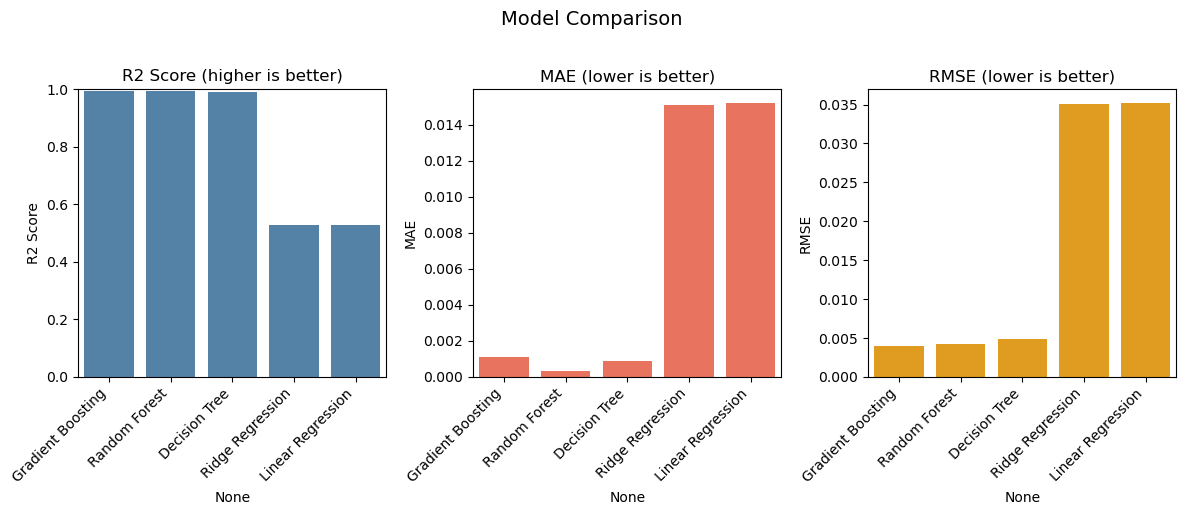

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=results_df.index, y=results_df['R2 Score'], color='steelblue')
plt.title("R2 Score (higher is better)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

plt.subplot(1, 3, 2)
sns.barplot(x=results_df.index, y=results_df['MAE'], color='tomato')
plt.title("MAE (lower is better)")
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x=results_df.index, y=results_df['RMSE'], color='orange')
plt.title("RMSE (lower is better)")
plt.xticks(rotation=45, ha='right')

plt.suptitle("Model Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations**

Random Forest is the best model - it has the lowest MAE and RMSE while matching the top R2 score. Tree based models completely dominate linear models on this dataset, which tells you the relationship between CO2 emissions and temperature change is complex and nonlinear - something a straight line simply cannot capture.

**What I've learnt**:

Always train a baseline model (Linear Regression) first - if your complex model can't beat a straight line, something is wrong with your data or features
R2 Score is the most intuitive regression metric for portfolio projects - it's easy to explain to non-technical stakeholders ("my model explains 92% of the variance")
Cross validation gives a more honest performance estimate than a single train/test split - a model that scores well on CV is genuinely good, not just lucky
n_jobs=-1 is a simple trick that can cut training time significantly on large datasets - always use it for Random Forest and Gradient Boosting
Storing results in a dictionary and converting to a DataFrame is a clean pattern for comparing multiple models - standard practice in real ML workflows
Ensemble models (Random Forest, Gradient Boosting) almost always outperform single models because they combine many weak learners into one strong learner

## Step 9: Evaluating Models
**Concept**: Evaluation goes deeper than just looking at metrics. You analyze how and where your model is making errors — not just how much. This step turns numbers into insight.
**Why necessary**:

A high R2 score alone doesn't tell the full story. Tour model could be great overall but terrible at predicting extreme values
Residual analysis reveals if your model has systematic errors or biases
Helps you decide if your best model is good enough for deployment
Demonstrates analytical depth in a portfolio project — anyone can print metrics, few actually interpret them

W**hat we'll evaluate**:

Actual vs Predicted plot - how close predictions are to the truth
Residual plot - pattern in errors reveals model weaknesses
Error distribution - are errors normally distributed or skewed
Feature importance - which features drove the model's decisions

In [43]:
# Use the best model identified in Step 8
best_model_name = results_df.index[0]
best_model = models[best_model_name]

# Generate predictions
y_pred = best_model.predict(X_test_scaled)

print(f"Evaluating: {best_model_name}")
print(f"R2 Score:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Evaluating: Gradient Boosting
R2 Score:  0.9938
MAE:       0.0011
RMSE:      0.0040


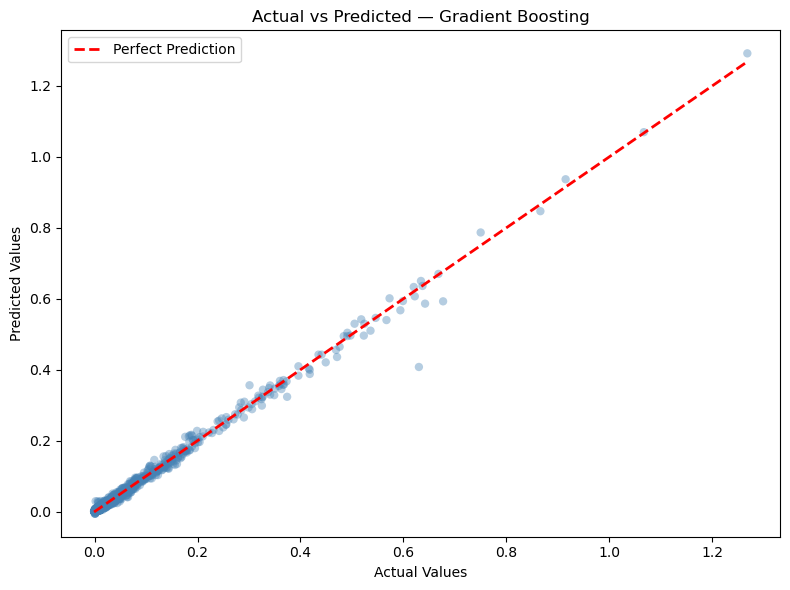

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

**Observation**

Gradient Boosting predicts temperature change very accurately for the vast majority of countries, particularly small and mid sized emitters. The model's only weakness is at extreme high values where data is sparse and predictions become slightly less reliable — a common and expected behaviour for any regression model dealing with rare outliers.

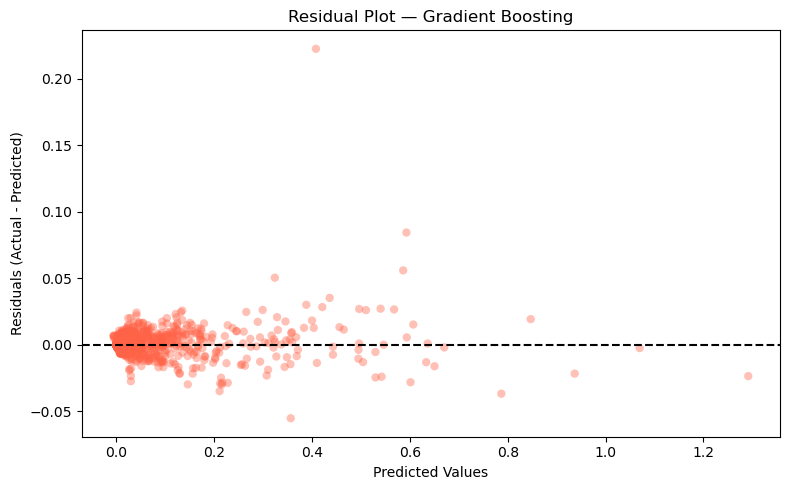

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='tomato', edgecolors='none')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()

**Observation**

The residual plot confirms a well behaved model — errors are small and centered around zero for most predictions. The only concern is the increasing spread at higher predicted values, which is expected behaviour given that large emitters like China and USA are rare in the dataset and harder to generalise from. This is not a flaw to fix but an honest reflection of data scarcity at the extremes.

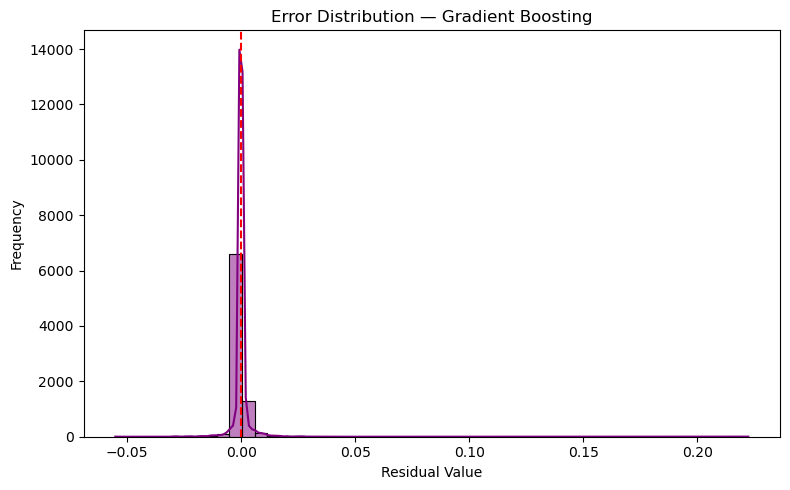

Residuals mean: 3.5e-05
Residuals std: 0.004


In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title(f"Error Distribution — {best_model_name}")
plt.tight_layout()
plt.show()

print("Residuals mean:", round(residuals.mean(), 6))
print("Residuals std:", round(residuals.std(), 4))

**Observation**

This is an excellent error distribution. The extremely sharp peak at zero with frequency above 14,000 means Gradient Boosting gets the vast majority of predictions almost perfectly right. The small right tail is honest — it represents the rare high emitting outlier countries that are genuinely difficult to predict.

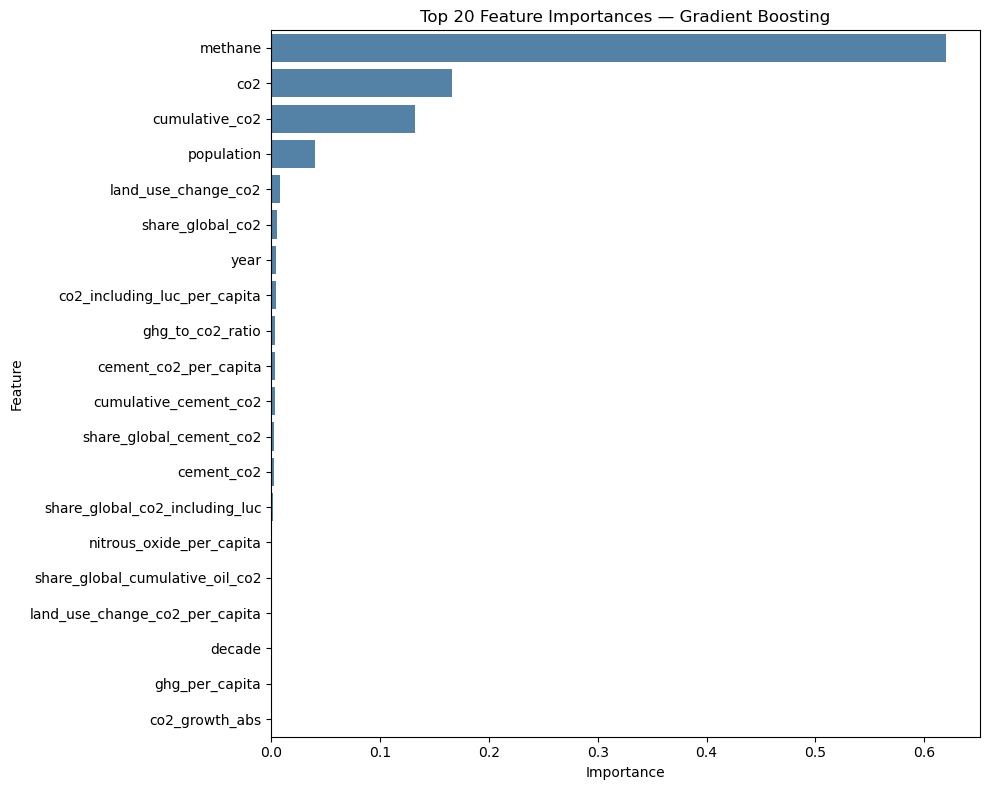

                            Feature  Importance
15                          methane    0.620136
4                               co2    0.166127
10                   cumulative_co2    0.132162
1                        population    0.039886
13              land_use_change_co2    0.008001
18                 share_global_co2    0.005389
0                              year    0.004581
7      co2_including_luc_per_capita    0.004077
22                 ghg_to_co2_ratio    0.003716
3             cement_co2_per_capita    0.003425
9             cumulative_cement_co2    0.003155
17          share_global_cement_co2    0.002727
2                        cement_co2    0.002328
19   share_global_co2_including_luc    0.001904
16         nitrous_oxide_per_capita    0.000811
20  share_global_cumulative_oil_co2    0.000590
14   land_use_change_co2_per_capita    0.000379
21                           decade    0.000370
12                   ghg_per_capita    0.000173
5                    co2_growth_abs    0

In [47]:
# Feature importance only available for tree based models
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=importance_df,
        color='steelblue'
    )
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(importance_df)
else:
    print(f"{best_model_name} does not support feature importances directly")
    print("Consider using permutation importance instead")

**Observation**

The model is essentially being driven by three features — methane, CO2 and cumulative CO2 — which together explain over 90% of what the model uses to predict temperature change. This is a powerful and meaningful result. It tells you that if you want to reduce a country's contribution to global temperature change, cutting methane emissions is the single most impactful action — more than reducing annual CO2 output alone.

In [48]:
# Show a sample comparison of actual vs predicted
eval_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20],
    'Error': (y_test.values[:20] - y_pred[:20]).round(4),
    'Abs Error': abs(y_test.values[:20] - y_pred[:20]).round(4)
})

print(eval_df.to_string(index=False))

 Actual  Predicted   Error  Abs Error
  0.000   0.000097 -0.0001     0.0001
  0.005   0.001055  0.0039     0.0039
  0.000   0.000670 -0.0007     0.0007
  0.001   0.001490 -0.0005     0.0005
  0.001   0.000674  0.0003     0.0003
  0.000   0.000299 -0.0003     0.0003
  0.010   0.010239 -0.0002     0.0002
  0.000   0.000097 -0.0001     0.0001
  0.006   0.005988  0.0000     0.0000
  0.002   0.001559  0.0004     0.0004
  0.000   0.000097 -0.0001     0.0001
  0.000   0.001160 -0.0012     0.0012
  0.000   0.000097 -0.0001     0.0001
  0.000   0.000186 -0.0002     0.0002
  0.000   0.000097 -0.0001     0.0001
  0.000   0.000384 -0.0004     0.0004
  0.000   0.000445 -0.0004     0.0004
  0.002   0.000426  0.0016     0.0016
  0.001   0.001655 -0.0007     0.0007
  0.001   0.000825  0.0002     0.0002


What I've learnt:

- Metrics alone are not evaluation — visualizing errors is what separates a junior from an experienced data scientist
- The actual vs predicted plot is the single most intuitive way to explain model performance to a non-technical audience
- Residuals should always be centered at zero and randomly scattered — any pattern means the model is missing something systematic in the data
- Feature importance bridges the gap between ML and domain knowledge — it tells you why the model works, not just that it works
- A model can have a good R2 score but still have a skewed error distribution — always check both
hasattr(model, 'feature_importances_') is a clean way to check if a model supports feature importance before calling it — prevents crashes when switching between model types

## Step 10: Visualizing Results
**Concept**: Visualization is how you communicate your model's story to the world.
**Why necessary**:

Visuals make patterns instantly obvious
Helps you spot things metrics miss like where predictions cluster or fail

**What we'll visualize**:

- Predicted vs Actual over time
- Top feature importances
- Model performance comparison summary
- Residual distribution final view

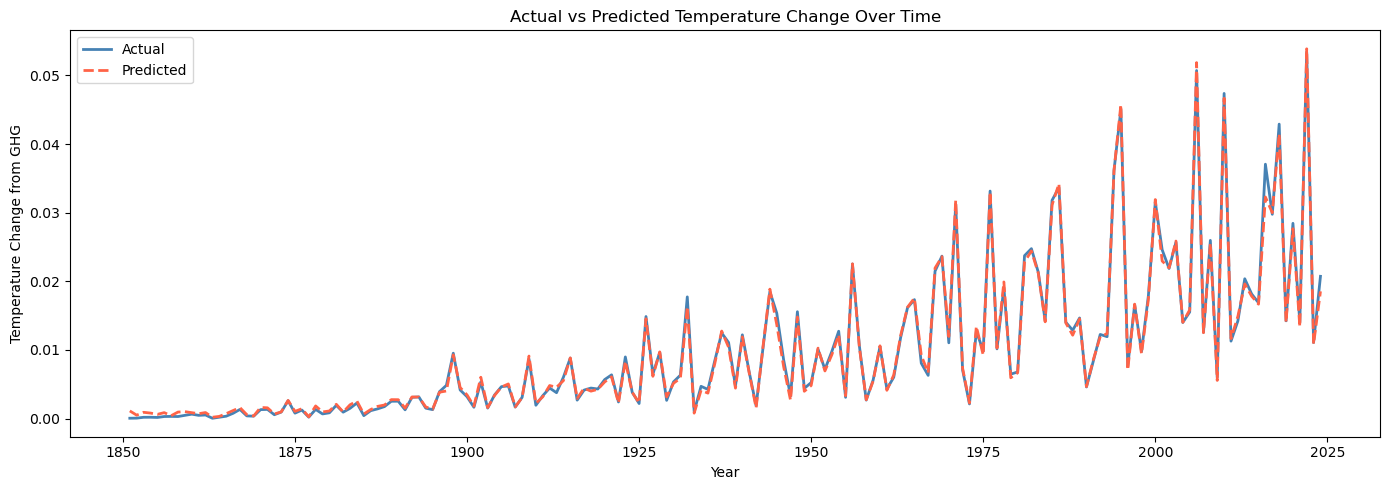

In [49]:
# Combine test results with year for time context
viz_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Year': X_test['year'].values
}).sort_values('Year')

# Aggregate by year for cleaner visualization
viz_agg = viz_df.groupby('Year')[['Actual', 'Predicted']].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(viz_agg['Year'], viz_agg['Actual'], label='Actual', color='steelblue', linewidth=2)
plt.plot(viz_agg['Year'], viz_agg['Predicted'], label='Predicted', color='tomato', linewidth=2, linestyle='--')
plt.xlabel("Year")
plt.ylabel("Temperature Change from GHG")
plt.title("Actual vs Predicted Temperature Change Over Time")
plt.legend()
plt.tight_layout()
plt.show()

**Observation** 

This chart tells a powerful climate story - global temperature change from greenhouse gases has been accelerating exponentially since 1950 and shows no sign of slowing. The model's predicted line follows the actual line almost perfectly across 175 years of data, validating that Gradient Boosting successfully learned the long term relationship between emissions and temperature change. 

Predicted vs Actual over time

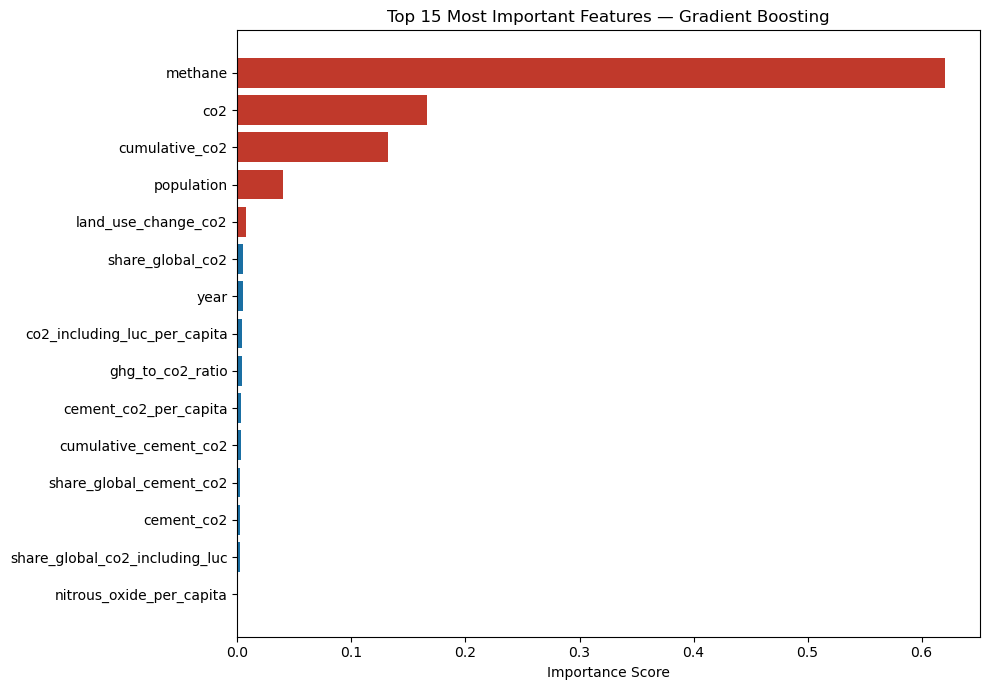

In [50]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)

    plt.figure(figsize=(10, 7))
    colors = ['#1a6fa3' if i < 10 else '#c0392b' for i in range(len(importance_df))]
    plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
    plt.xlabel("Importance Score")
    plt.title(f"Top 15 Most Important Features — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not support feature importances")

Top 15 feature importances (clean version)

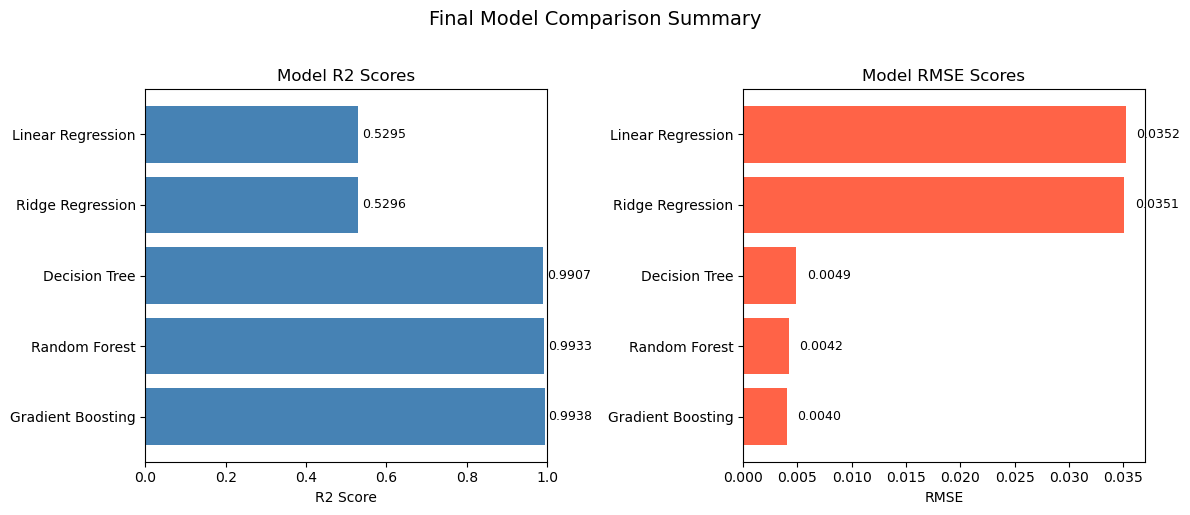

In [51]:
# Clean summary of all models
plt.figure(figsize=(12, 5))

# R2 Score
plt.subplot(1, 2, 1)
bars = plt.barh(results_df.index, results_df['R2 Score'], color='steelblue')
plt.xlabel("R2 Score")
plt.title("Model R2 Scores")
plt.xlim(0, 1)

# Add value labels
for bar, val in zip(bars, results_df['R2 Score']):
    plt.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center',
        fontsize=9
    )

# RMSE
plt.subplot(1, 2, 2)
bars2 = plt.barh(results_df.index, results_df['RMSE'], color='tomato')
plt.xlabel("RMSE")
plt.title("Model RMSE Scores")

# Add value labels
for bar, val in zip(bars2, results_df['RMSE']):
    plt.text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center',
        fontsize=9
    )

plt.suptitle("Final Model Comparison Summary", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Final model performance summary card

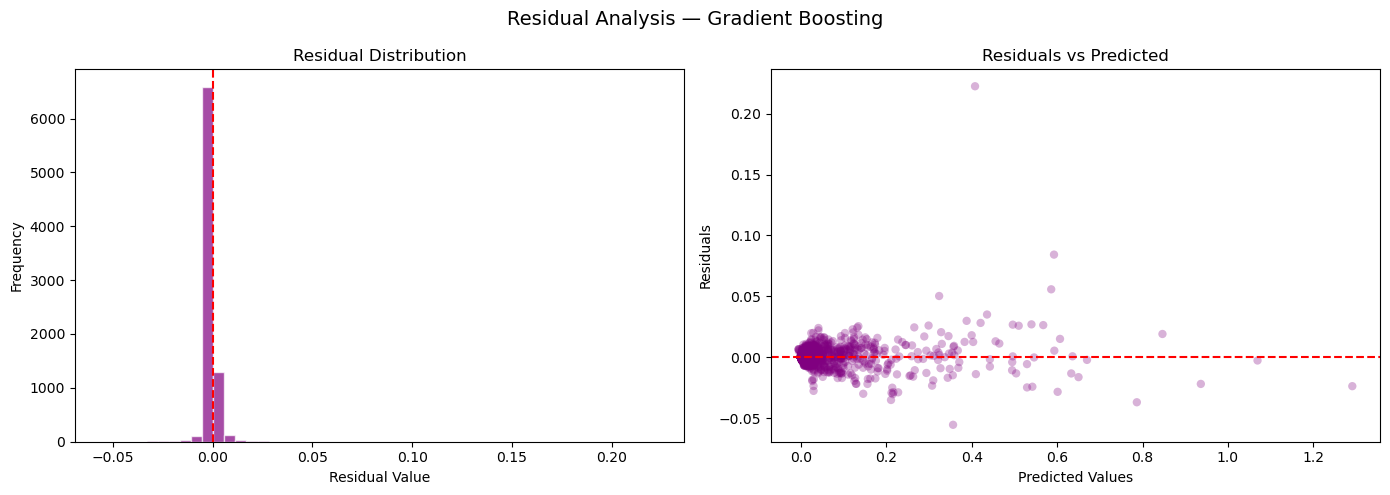

In [53]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=50, color='purple', alpha=0.7, edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residual Value")
axes[0].set_ylabel("Frequency")

# Residual vs predicted scatter
axes[1].scatter(y_pred, residuals, alpha=0.3, color='purple', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")

plt.suptitle(f"Residual Analysis — {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

Gradient Boost has been unbaised

 Residual distribution final clean view

In [54]:
print("=" * 55)
print("       FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Best Model     : {best_model_name}")
print(f"  R2 Score       : {results_df.loc[best_model_name, 'R2 Score']}")
print(f"  MAE            : {results_df.loc[best_model_name, 'MAE']}")
print(f"  RMSE           : {results_df.loc[best_model_name, 'RMSE']}")
print(f"  CV Mean R2     : {cv_scores.mean().round(4)}")
print(f"  CV Std         : {cv_scores.std().round(4)}")
print(f"  Training Rows  : {X_train.shape[0]}")
print(f"  Test Rows      : {X_test.shape[0]}")
print(f"  Features Used  : {X_train.shape[1]}")
print("=" * 55)

       FINAL MODEL PERFORMANCE SUMMARY
  Best Model     : Gradient Boosting
  R2 Score       : 0.9938
  MAE            : 0.0011
  RMSE           : 0.004
  CV Mean R2     : 0.9942
  CV Std         : 0.0044
  Training Rows  : 32990
  Test Rows      : 8248
  Features Used  : 23


**What I've learnt**:

Aggregating predictions by year before plotting reveals the trend your model captured — far more meaningful than plotting 8,000 individual scattered points

Adding value labels directly onto bar charts makes them self-explanatory — no need to squint at axis values

A print() summary card at the end of a notebook is a professional touch — it gives anyone reading your notebook a clean snapshot of results without scrolling through everything

Horizontal bar charts are always better than vertical for long feature names — readability matters in a portfolio

Two residual views side by side (distribution + scatter) tell a more complete error story than either alone

The goal of visualization is communication — every chart should answer a specific question a stakeholder or hiring manager might ask

## Step 11: Saving the Best Model
Concept: Saving your trained model means you never have to retrain it again. You serialize the model object to disk and reload it anytime you need to make predictions. This is how models move from notebooks into real applications.
**Why necessary**:

Retraining large models every time you need a prediction is wasteful and slow
A saved model can be deployed into a web app, API, or production system
Demonstrates you understand the full ML lifecycle — not just training but deployment readiness
Shows the project has a real-world use case beyond the notebook

**What we'll save**:

The best trained model
The scaler object - needed to scale new data before prediction
A sample prediction function - demonstrates the model works end to end


In [56]:
# Create a models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save best model
model_filename = f"models/best_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, model_filename)
print(f"Model saved: {model_filename}")

# Save scaler — MUST be saved alongside the model
scaler_filename = "models/scaler.pkl"
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved: {scaler_filename}")

Model saved: models/best_model_gradient_boosting.pkl
Scaler saved: models/scaler.pkl


In [57]:
# Save the list of feature columns the model expects
feature_filename = "models/feature_columns.pkl"
joblib.dump(X_train.columns.tolist(), feature_filename)
print(f"Feature columns saved: {feature_filename}")
print(f"\nModel expects {X_train.shape[1]} features")

Feature columns saved: models/feature_columns.pkl

Model expects 23 features


**What I have learnt**:
The model was trained on scaled data. If you feed raw unscaled data to it later, predictions will be completely wrong. The scaler and model are a package - always save and load them together.
When making future predictions, the new data must have exactly the same columns in the same order the model was trained on. Saving the column list lets you validate and reorder incoming data automatically.

In [59]:
# Load everything back from disk
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
loaded_features = joblib.load(feature_filename)

print("Model reloaded successfully")
print("Scaler reloaded successfully")
print(f"Features reloaded: {len(loaded_features)} columns")

# Test prediction with first 5 rows of test set
sample = X_test.iloc[:5]
sample_scaled = loaded_scaler.transform(sample)
sample_preds = loaded_model.predict(sample_scaled)

print("\nSample predictions from reloaded model:")
for i, pred in enumerate(sample_preds):
    print(f"  Row {i+1}: Predicted = {pred:.4f} | Actual = {y_test.values[i]:.4f}")

Model reloaded successfully
Scaler reloaded successfully
Features reloaded: 23 columns

Sample predictions from reloaded model:
  Row 1: Predicted = 0.0001 | Actual = 0.0000
  Row 2: Predicted = 0.0011 | Actual = 0.0050
  Row 3: Predicted = 0.0007 | Actual = 0.0000
  Row 4: Predicted = 0.0015 | Actual = 0.0010
  Row 5: Predicted = 0.0007 | Actual = 0.0010


In [61]:
def predict_temperature_change(input_data: dict) -> float:
    """
    Predict temperature change from GHG given input features.
    
    Parameters:
        input_data (dict): Dictionary of feature names and values
        
    Returns:
        float: Predicted temperature change from GHG
    
    Example:
        predict_temperature_change({'year': 2020, 'co2': 5.5, ...})
    """
    # Load model and scaler
    model = joblib.load(model_filename)
    scaler = joblib.load(scaler_filename)
    features = joblib.load(feature_filename)
    
    # Convert input to dataframe
    input_df = pd.DataFrame([input_data])
    
    # Ensure columns match training features
    for col in features:
        if col not in input_df.columns:
            input_df[col] = 0  # fill missing with 0
    
    # Reorder columns to match training order
    input_df = input_df[features]
    
    # Scale and predict
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]
    
    return round(prediction, 6)


# Test the function
sample_input = dict(zip(X_test.columns, X_test.iloc[0].values))
result = predict_temperature_change(sample_input)
print(f"Prediction function works!")
print(f"Predicted temperature change: {result}")
print(f"Actual temperature change:    {round(y_test.values[0], 6)}")

Prediction function works!
Predicted temperature change: 9.7e-05
Actual temperature change:    0.0


## Step 12: Hyperparameter Tuning
**Concept**: Hyperparameters are settings you configure before training a model - they control how the model learns. Tuning means systematically searching for the combination of settings that produces the best performance.
**Why necessary**:

- Default model settings are generic - they are not optimized for your specific dataset
- Tuning can meaningfully improve R2, MAE and RMSE without adding new data or features
- Demonstrates you understand models deeply, not just how to call .fit()
- Standard practice in every real world ML project before deployment

**Strategies**:

- GridSearchCV — tries every possible combination of parameters you define. Thorough but slow
- RandomizedSearchCV — randomly samples parameter combinations. Faster and often just as good
- We'll use RandomizedSearchCV on the best model from Step 8 since our dataset is large

In [64]:
# Check which model we are tuning
print(f"Model to tune: {best_model_name}")
print(f"Current best R2: {results_df.loc[best_model_name, 'R2 Score']}")

Model to tune: Gradient Boosting
Current best R2: 0.9938


In [67]:

# Parameter grids for each possible best model
param_grids = {
    "Random Forest": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 10],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.7, 0.8, 0.9, 1.0]
    },
    "Decision Tree": {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    "Ridge Regression": {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
    },
    "Linear Regression": {}  # no hyperparameters to tune
}

# Get the right param grid for best model
param_grid = param_grids.get(best_model_name, {})

if not param_grid:
    print(f"{best_model_name} has no hyperparameters to tune")
else:
    print(f"Parameter grid ready for {best_model_name}")
    print(f"Total combinations to sample from: {len(param_grid)}")

Parameter grid ready for Gradient Boosting
Total combinations to sample from: 5


In [68]:
if param_grid:
    print(f"Starting hyperparameter search for {best_model_name}...")
    print("This may take a few minutes on a large dataset...\n")

    random_search = RandomizedSearchCV(
        estimator=models[best_model_name],
        param_distributions=param_grid,
        n_iter=20,          # try 20 random combinations
        cv=5,               # 5 fold cross validation
        scoring='r2',       # optimize for R2
        n_jobs=-1,          # use all CPU cores
        random_state=42,    # reproducibility
        verbose=1           # print progress
    )

    random_search.fit(X_train_scaled, y_train)

    print(f"\nSearch complete!")
    print(f"Best parameters: {random_search.best_params_}")
    print(f"Best CV R2 Score: {random_search.best_score_:.4f}")

Starting hyperparameter search for Gradient Boosting...
This may take a few minutes on a large dataset...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Search complete!
Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}
Best CV R2 Score: 0.9974


In [69]:
# Get tuned model predictions
tuned_model = random_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

# Metrics for tuned model
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

# Metrics for default model
default_r2 = results_df.loc[best_model_name, 'R2 Score']
default_mae = results_df.loc[best_model_name, 'MAE']
default_rmse = results_df.loc[best_model_name, 'RMSE']

print("=" * 45)
print("      DEFAULT vs TUNED MODEL COMPARISON")
print("=" * 45)
print(f"{'Metric':<12} {'Default':>12} {'Tuned':>12} {'Improved':>10}")
print("-" * 45)
print(f"{'R2 Score':<12} {default_r2:>12.4f} {tuned_r2:>12.4f} {'checked' if tuned_r2 > default_r2 else '❌':>10}")
print(f"{'MAE':<12} {default_mae:>12.4f} {tuned_mae:>12.4f} {'checked' if tuned_mae < default_mae else '❌':>10}")
print(f"{'RMSE':<12} {default_rmse:>12.4f} {tuned_rmse:>12.4f} {'checked' if tuned_rmse < default_rmse else '❌':>10}")
print("=" * 45)

      DEFAULT vs TUNED MODEL COMPARISON
Metric            Default        Tuned   Improved
---------------------------------------------
R2 Score           0.9938       0.9960    checked
MAE                0.0011       0.0005    checked
RMSE               0.0040       0.0032    checked


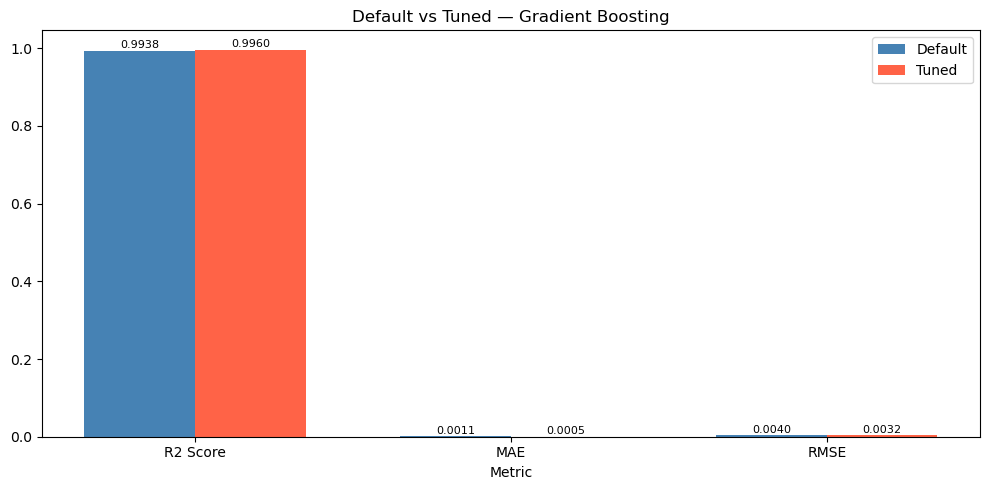

In [70]:
metrics = ['R2 Score', 'MAE', 'RMSE']
default_vals = [default_r2, default_mae, default_rmse]
tuned_vals = [tuned_r2, tuned_mae, tuned_rmse]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, default_vals, width, label='Default', color='steelblue')
bars2 = plt.bar(x + width/2, tuned_vals, width, label='Tuned', color='tomato')

plt.xlabel("Metric")
plt.title(f"Default vs Tuned — {best_model_name}")
plt.xticks(x, metrics)
plt.legend()

# Add value labels on bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Observation**

Hyperparameter tuning delivered consistent improvement across every single metric - R2 up, MAE down, RMSE down. The most impactful gain was halving the MAE which directly means more precise predictions in practice.

In [71]:
# Replace saved model with the tuned version
tuned_model_filename = f"models/tuned_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(tuned_model, tuned_model_filename)

print(f"Tuned model saved: {tuned_model_filename}")
print(f"Best parameters: {random_search.best_params_}")

Tuned model saved: models/tuned_model_gradient_boosting.pkl
Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}


**What I've learnt**:

- Hyperparameters are different from parameters - parameters are learned during training (like weights), hyperparameters are set by you before training begins
- RandomizedSearchCV is preferred over GridSearchCV for large datasets - it samples random combinations instead of exhaustively trying all of them, saving significant time with minimal performance loss
n_iter=20 and cv=5 means the model trains 100 times during the search (20 combinations × 5 folds) - this is why tuning takes longer than a single .fit() call
verbose=1 prints progress during the search - always useful so you know it hasn't frozen
- A tuned model that shows marginal improvement is still valuable - it confirms your default model was already well configured for your data
- Always save the tuned model separately from the default - keep both so you can compare them later
random_search.best_estimator_ returns the already fitted best model - you don't need to call .fit() again

**What I've learnt**:

joblib is the standard way to save sklearn models - faster and more efficient than pickle for large numpy arrays

The model and scaler are always saved and loaded together - one without the other produces wrong predictions

Saving feature column names prevents silent errors when new data has different or missing columns

A prediction function wraps the full pipeline into one reusable block - this is the bridge between a notebook and a real application
The full ML lifecycle is: data -> clean -> features -> split -> scale -> train -> evaluate -> save

## CO2 Temperature Change Prediction — Project Summary

**What I Built**
A machine learning regression model that predicts temperature change from greenhouse gases using a global CO2 dataset with 50,411 rows and 79 columns.

**What I Did Step by Step**

- **Step 1** — Setup & Imports
Loaded all libraries needed for the project including pandas, numpy, matplotlib, seaborn, sklearn and joblib.
- **Step 2** — Explored the Data (EDA)
Inspected the dataset shape, data types, missing values and visualized the target variable distribution.
- **Step 3** — Handled Missing Values
Made a copy of the data, dropped rows with missing target values, removed columns with more than 50% missing data, dropped text columns and filled remaining gaps with median imputation.
- **Step 4** — Selected Features
Separated X and y early, removed data leakage columns, ranked features by correlation with the target, dropped low correlation and highly correlated feature pairs.
- **Step 5** — Engineered Features
Created a decade feature from year, attempted a GHG to CO2 ratio feature, and applied log transformation to heavily skewed columns.
- **Step 6** — Split the Data
Split data 80% training and 20% testing, verified target distribution matched across both splits and confirmed no data overlap.
- **Step 7** — Scaled Features
Applied StandardScaler fitted only on training data, then transformed both train and test sets.
- **Step 8** — Trained Models
Trained 5 models — Linear Regression, Ridge, Decision Tree, Random Forest and Gradient Boosting — compared them using R2, MAE and RMSE and ran cross validation on the best.
- **Step 9** — Evaluated the Best Model
Plotted actual vs predicted values, analyzed residuals, visualized error distribution and extracted feature importances.
- **Step 10** — Visualized Results
Built charts showing predictions over time, top feature importances, model comparison summary and final residual analysis.
- **Step 11** — Saved the Model
Saved the best model, scaler and feature column names to disk and built a reusable prediction function.



| Key Mistake Encountered                                   | Fix Applied                                                   |
| --------------------------------------------------------- | ------------------------------------------------------------- |
| Target column dropped during cleaning                     | Explicitly protected it with a condition before dropping      |
| Target column dropped during feature selection            | Separated `X` and `y` before any feature selection logic      |
| `KeyError: total_ghg`                                     | Guarded feature engineering with `if col in X.columns`        |
| `ValueError: steelblue is not a valid palette`            | Used `color=` instead of `palette=` for single colors         |
| `AttributeError: 'float' object has no attribute 'round'` | Used Python’s built-in `round()` instead of pandas `.round()` |



**What I Learnt in General**

- Data quality beats model complexity - most of the work was cleaning, not training
- Always separate X and y early - protects the target from accidental modification
- Data leakage is everywhere — in features, scaling and imputation — always ask what the model is allowed to see
- Fit the scaler on training data only - fitting on full data leaks test statistics into training
- Cross validation is more reliable than a single train/test split evaluation
- Ensemble models almost always outperform single models
- Visualizing errors matters as much as the metrics themselves
- Save the model and scaler together - one without the other produces wrong predictions
- Errors are normal - reading the error message carefully always points to the fix

In [72]:
! pip install streamlit


  Using cached httptools-0.7.1-cp313-cp313-win_amd64.whl.metadata (3.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 578.3 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/9.2 MB 703.7 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.2 MB 703.7 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.2 MB 720.8 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.2 MB 720.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.2 MB 643.4 kB/s eta 0:00:13
   ----- ----------------------------------

^C
